# Karachi Crime Dataset - Exploratory Data Analysis (EDA)

**Objective:** Perform comprehensive exploratory data analysis on the Karachi Crime Dataset to understand patterns, distributions, and relationships that will inform ML model development.

---

## Step 1: Setup & Load Data

In [42]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import folium
from folium.plugins import MarkerCluster
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the dataset
df = pd.read_csv('Raw Data/karachi_crime_dataset.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nExpected: 100,000 rows × 21 columns")
print(f"Match: {df.shape == (100000, 21)}")

Dataset loaded successfully!
Shape: 100,000 rows × 21 columns

Expected: 100,000 rows × 21 columns
Match: True


---
## Step 2: Initial Inspection

In [5]:
# Display first few rows
print("=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
df.head()

FIRST 5 ROWS


,INCIDENT_ID,TOWN,TOWN_RISK_LEVEL,TOWN_PRIORITY_RANK,SUBDIVISION,SUBDIVISION_RISK_LEVEL,SUBDIVISION_PRIORITY_RANK,SEVERITY_SCORE,SEVERITY,DATE,LATITUDE,LONGITUDE,CRIME_TYPE,IS_RED_ZONE,IS_ORANGE_ZONE,IS_YELLOW_ZONE,IS_GREEN_ZONE,IS_WHITE_ZONE,RISK_ZONE,SOURCE,RANK
0,INCIDENT_000001,Lyari Town,High,1,Baghdadi,High,1,10,High,2024-12-15,24.86,67.00,Gang Violence,1,0,0,0,0,Red,Synthetic,1
1,INCIDENT_000002,Lyari Town,High,1,Baghdadi,High,1,10,High,2020-12-03,24.86,67.00,Murder,1,0,0,0,0,Red,Synthetic,1
2,INCIDENT_000003,Lyari Town,High,1,Baghdadi,High,1,10,High,2025-01-24,24.86,67.00,Murder,1,0,0,0,0,Red,Synthetic,1
3,INCIDENT_000004,Lyari Town,High,1,Baghdadi,High,1,10,High,2023-02-18,24.86,67.00,Gang Violence,1,0,0,0,0,Red,Synthetic,1
4,INCIDENT_000005,Lyari Town,High,1,Baghdadi,High,1,10,High,2025-04-13,24.86,67.00,Gang Violence,1,0,0,0,0,Red,Synthetic,1


In [6]:
# Display last few rows
print("=" * 80)
print("LAST 5 ROWS")
print("=" * 80)
df.tail()

LAST 5 ROWS


,INCIDENT_ID,TOWN,TOWN_RISK_LEVEL,TOWN_PRIORITY_RANK,SUBDIVISION,SUBDIVISION_RISK_LEVEL,SUBDIVISION_PRIORITY_RANK,SEVERITY_SCORE,SEVERITY,DATE,LATITUDE,LONGITUDE,CRIME_TYPE,IS_RED_ZONE,IS_ORANGE_ZONE,IS_YELLOW_ZONE,IS_GREEN_ZONE,IS_WHITE_ZONE,RISK_ZONE,SOURCE,RANK
99995,INCIDENT_099996,Korangi Town,High,1,Bilal Colony,High,1,10,High,2022-06-17,24.85,67.13,Gang Violence,1,0,0,0,0,Red,Synthetic,0
99996,INCIDENT_099997,Korangi Town,High,1,Bilal Colony,High,1,10,High,2021-12-21,24.85,67.13,Murder,1,0,0,0,0,Red,Synthetic,0
99997,INCIDENT_099998,Korangi Town,High,1,Bilal Colony,High,1,5,Medium,2021-07-08,24.85,67.13,Industrial Hazards,1,0,0,0,0,Red,Synthetic,0
99998,INCIDENT_099999,Korangi Town,High,1,Bilal Colony,High,1,10,High,2023-09-24,24.85,67.13,Extortion,1,0,0,0,0,Red,Synthetic,0
99999,INCIDENT_100000,Korangi Town,High,1,Bilal Colony,High,1,5,Medium,2023-10-20,24.85,67.13,Drug Possession,1,0,0,0,0,Red,Synthetic,0


In [7]:
# Display random sample
print("=" * 80)
print("RANDOM SAMPLE (5 ROWS)")
print("=" * 80)
df.sample(5, random_state=42)

RANDOM SAMPLE (5 ROWS)


,INCIDENT_ID,TOWN,TOWN_RISK_LEVEL,TOWN_PRIORITY_RANK,SUBDIVISION,SUBDIVISION_RISK_LEVEL,SUBDIVISION_PRIORITY_RANK,SEVERITY_SCORE,SEVERITY,DATE,LATITUDE,LONGITUDE,CRIME_TYPE,IS_RED_ZONE,IS_ORANGE_ZONE,IS_YELLOW_ZONE,IS_GREEN_ZONE,IS_WHITE_ZONE,RISK_ZONE,SOURCE,RANK
75721,INCIDENT_075722,Jamshed Town,Medium,3,PECHS,Medium,2,5,Medium,2020-07-21,24.87,67.06,Theft,0,0,1,0,0,Yellow,Synthetic,0
80184,INCIDENT_080185,Bin Qasim Town,Medium,3,Gulshan-e-Hadeed,Medium–High,2,8,High,2022-07-12,24.87,67.37,Land Grabbing,0,1,0,0,0,Orange,Synthetic,0
19864,INCIDENT_019865,Baldia Town,High,1,Ittehad Town,High,1,9,High,2024-08-25,24.94,66.96,Political Violence,1,0,0,0,0,Red,Synthetic,0
76699,INCIDENT_076700,Gadap Town,Medium,3,Taiser Town,High,1,10,High,2020-07-12,25.04,67.10,Kidnapping,1,0,0,0,0,Red,Synthetic,0
92991,INCIDENT_092992,Saddar Town,Low,4,Regal Chowk,High,1,9,High,2020-07-19,24.86,67.01,Theft,1,0,0,0,0,Red,Synthetic,10


In [8]:
# Dataset information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   INCIDENT_ID                100000 non-null  object 
 1   TOWN                       100000 non-null  object 
 2   TOWN_RISK_LEVEL            100000 non-null  object 
 3   TOWN_PRIORITY_RANK         100000 non-null  int64  
 4   SUBDIVISION                100000 non-null  object 
 5   SUBDIVISION_RISK_LEVEL     100000 non-null  object 
 6   SUBDIVISION_PRIORITY_RANK  100000 non-null  int64  
 7   SEVERITY_SCORE             100000 non-null  int64  
 8   SEVERITY                   100000 non-null  object 
 9   DATE                       100000 non-null  object 
 10  LATITUDE                   100000 non-null  float64
 11  LONGITUDE                  100000 non-null  float64
 12  CRIME_TYPE                 100000 non-null  object 
 13  IS_RED_ZON

In [9]:
# Numerical summary
print("=" * 80)
print("NUMERICAL SUMMARY")
print("=" * 80)
df.describe()

NUMERICAL SUMMARY


,TOWN_PRIORITY_RANK,SUBDIVISION_PRIORITY_RANK,SEVERITY_SCORE,LATITUDE,LONGITUDE,IS_RED_ZONE,IS_ORANGE_ZONE,IS_YELLOW_ZONE,IS_GREEN_ZONE,IS_WHITE_ZONE,RANK
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,2.20,1.78,7.47,24.89,67.06,0.41,0.06,0.35,0.19,0.00,3.22
std,1.25,0.74,2.35,0.06,0.07,0.49,0.23,0.48,0.39,0.00,6.89
min,1.00,1.00,1.00,24.55,66.96,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,6.00,24.86,67.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2.00,2.00,8.00,24.89,67.06,0.00,0.00,0.00,0.00,0.00,0.00
75%,4.00,2.00,10.00,24.94,67.12,1.00,0.00,1.00,0.00,0.00,1.00
max,4.00,3.00,10.00,25.08,67.37,1.00,1.00,1.00,1.00,0.00,30.00


In [10]:
# Categorical summary
print("=" * 80)
print("CATEGORICAL SUMMARY")
print("=" * 80)
df.describe(include='object')

CATEGORICAL SUMMARY


,INCIDENT_ID,TOWN,TOWN_RISK_LEVEL,SUBDIVISION,SUBDIVISION_RISK_LEVEL,SEVERITY,DATE,CRIME_TYPE,RISK_ZONE,SOURCE
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,18,3,194,4,3,1826,27,4,1
top,INCIDENT_099961,Orangi Town,High,Baghdadi,High,High,2022-09-26,Robbery,Red,Synthetic
freq,1,11501,48889,2143,40670,55111,83,10269,40670,100000


---
## Step 3: Data Quality Check

In [11]:
# Check missing values
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) == 0:
    print("✓ No missing values found!")
else:
    print(missing_df.to_string(index=False))

MISSING VALUES ANALYSIS
✓ No missing values found!


In [12]:
# Check duplicates
print("=" * 80)
print("DUPLICATE ROWS CHECK")
print("=" * 80)

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")

if duplicate_count == 0:
    print("✓ No duplicate rows found!")
else:
    print(f"⚠ Warning: {duplicate_count:,} duplicate rows detected")

DUPLICATE ROWS CHECK
Number of duplicate rows: 0
✓ No duplicate rows found!


In [13]:
# Verify INCIDENT_ID uniqueness
print("=" * 80)
print("INCIDENT_ID UNIQUENESS CHECK")
print("=" * 80)

unique_ids = df['INCIDENT_ID'].nunique()
total_rows = len(df)

print(f"Total rows: {total_rows:,}")
print(f"Unique INCIDENT_IDs: {unique_ids:,}")
print(f"All IDs unique: {unique_ids == total_rows}")

if unique_ids == total_rows:
    print("✓ All INCIDENT_IDs are unique!")
else:
    print(f"⚠ Warning: {total_rows - unique_ids:,} duplicate INCIDENT_IDs found")

INCIDENT_ID UNIQUENESS CHECK
Total rows: 100,000
Unique INCIDENT_IDs: 100,000
All IDs unique: True
✓ All INCIDENT_IDs are unique!


In [14]:
# Convert DATE column to datetime
print("=" * 80)
print("DATE COLUMN CONVERSION")
print("=" * 80)

print(f"Original data type: {df['DATE'].dtype}")
df['DATE'] = pd.to_datetime(df['DATE'])
print(f"Converted data type: {df['DATE'].dtype}")
print(f"\nDate range: {df['DATE'].min()} to {df['DATE'].max()}")
print("✓ Date conversion successful!")

DATE COLUMN CONVERSION
Original data type: object
Converted data type: datetime64[ns]

Date range: 2020-06-01 00:00:00 to 2025-05-31 00:00:00
✓ Date conversion successful!


---
## Step 4: Univariate Analysis

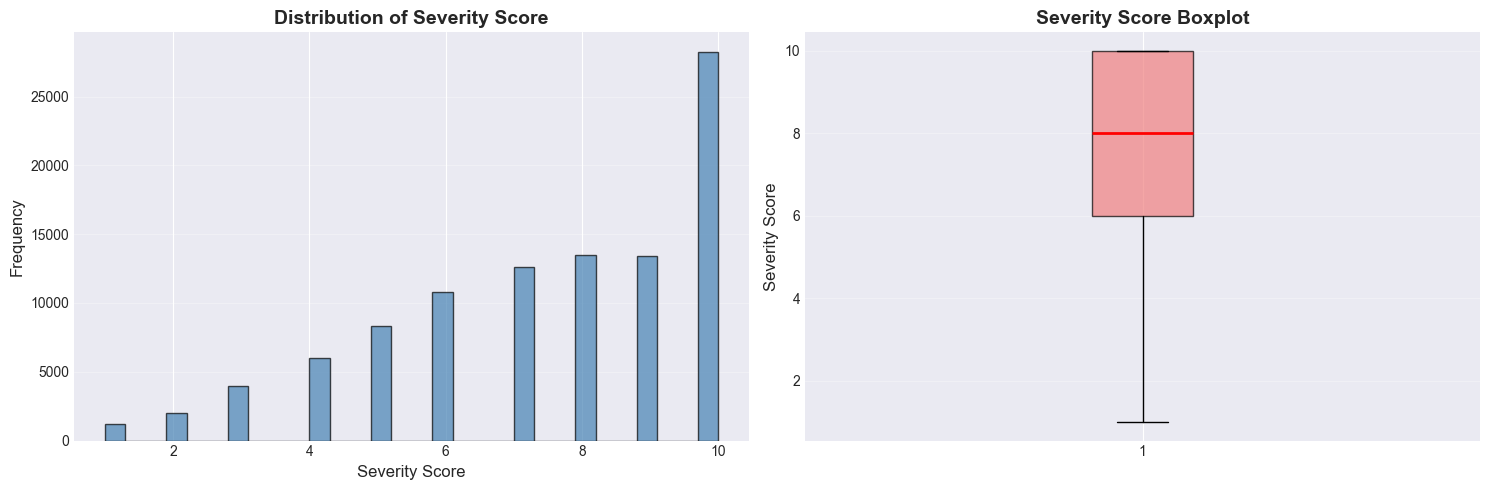

Mean: 7.47
Median: 8.00
Std Dev: 2.35


In [15]:
# SEVERITY_SCORE histogram + boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['SEVERITY_SCORE'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Severity Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Severity Score', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
axes[1].boxplot(df['SEVERITY_SCORE'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Severity Score', fontsize=12)
axes[1].set_title('Severity Score Boxplot', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean: {df['SEVERITY_SCORE'].mean():.2f}")
print(f"Median: {df['SEVERITY_SCORE'].median():.2f}")
print(f"Std Dev: {df['SEVERITY_SCORE'].std():.2f}")

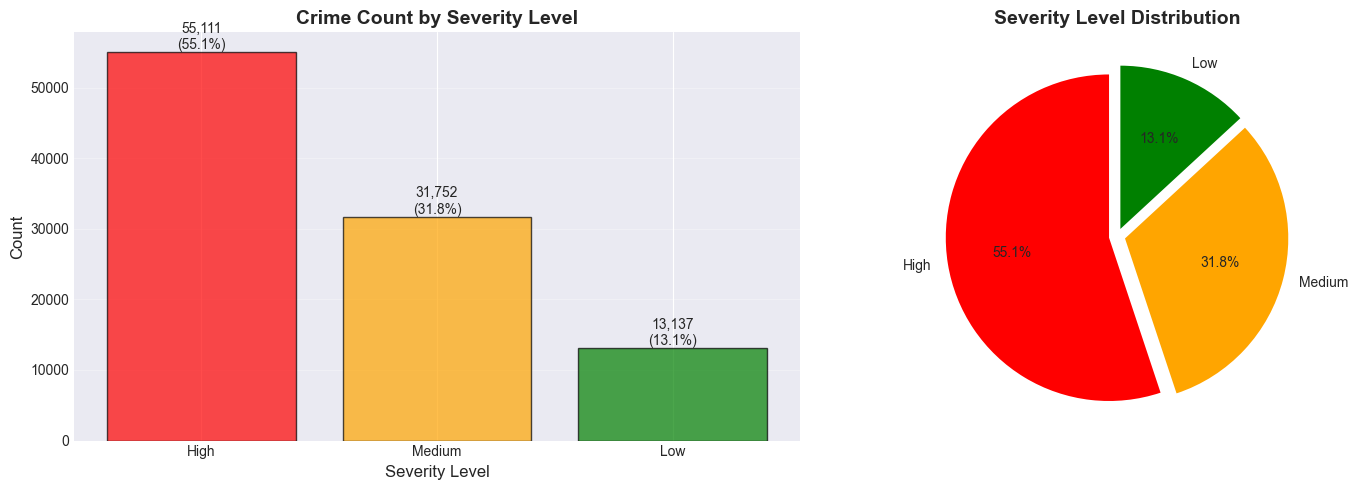

In [16]:
# SEVERITY level bar chart + pie chart
severity_counts = df['SEVERITY'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
colors_bar = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}
bar_colors = [colors_bar.get(x, 'gray') for x in severity_counts.index]
bars = axes[0].bar(severity_counts.index, severity_counts.values, color=bar_colors, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Severity Level', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Crime Count by Severity Level', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)

# Pie chart
colors_pie = [colors_bar.get(x, 'gray') for x in severity_counts.index]
axes[1].pie(severity_counts.values, labels=severity_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90, explode=[0.05]*len(severity_counts))
axes[1].set_title('Severity Level Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

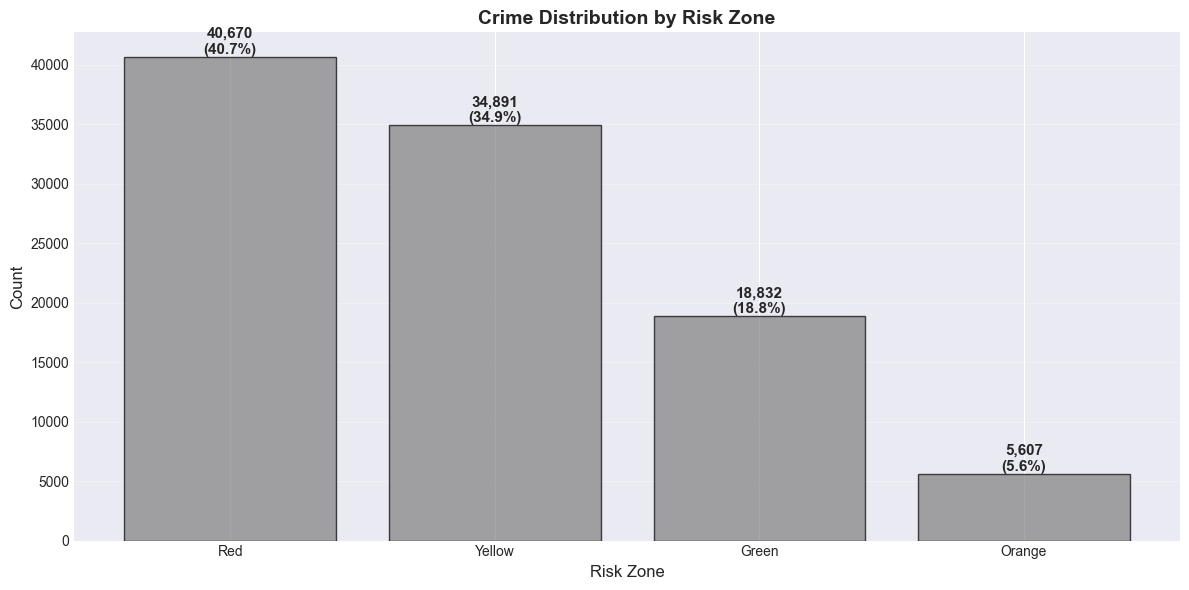

In [17]:
# RISK_ZONE distribution
risk_zone_counts = df['RISK_ZONE'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors_risk = {'High': 'darkred', 'Medium': 'darkorange', 'Low': 'darkgreen'}
bar_colors = [colors_risk.get(x, 'gray') for x in risk_zone_counts.index]
bars = ax.bar(risk_zone_counts.index, risk_zone_counts.values, color=bar_colors, edgecolor='black', alpha=0.7)

ax.set_xlabel('Risk Zone', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Crime Distribution by Risk Zone', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

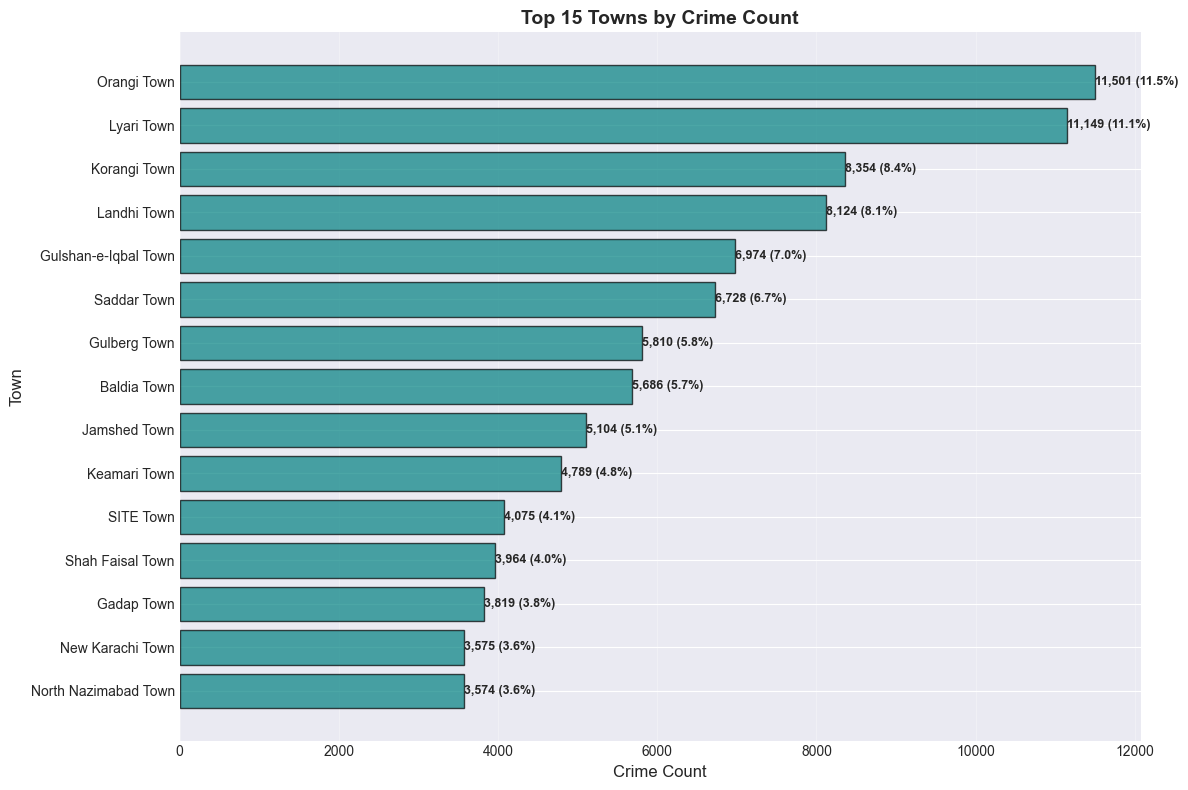

In [18]:
# Top 15 TOWNs by crime count
top_towns = df['TOWN'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_towns)), top_towns.values, color='teal', edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(top_towns)))
ax.set_yticklabels(top_towns.index)
ax.set_xlabel('Crime Count', fontsize=12)
ax.set_ylabel('Town', fontsize=12)
ax.set_title('Top 15 Towns by Crime Count', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width):,} ({width/len(df)*100:.1f}%)',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 5: Target Variable Analysis (CRIME_TYPE)

In [19]:
# Crime type value counts
print("=" * 80)
print("TARGET VARIABLE: CRIME_TYPE DISTRIBUTION")
print("=" * 80)

crime_type_counts = df['CRIME_TYPE'].value_counts()
print(crime_type_counts)
print("\n" + "=" * 80)

TARGET VARIABLE: CRIME_TYPE DISTRIBUTION
CRIME_TYPE
Robbery                10269
Snatching              10051
Murder                  8138
Theft                   7634
Gang Violence           7247
Political Violence      5970
Assault                 5907
Drug Possession         5706
Homicide                5668
Gang Activity           5370
Land Grabbing           5269
Extortion               5255
Kidnapping              5234
Industrial Hazards      5009
Shootings                944
Gun Violence             821
Cellphone Snatching      757
Street Crimes            674
Drug Mafia Activity      657
Mugging                  641
Targeted Killing         613
Industrial Theft         517
Street Snatching         398
Ethnic Conflict          390
Phone Theft              388
Violence                 349
Mobile Snatching         124
Name: count, dtype: int64



In [24]:
#Fixing crime types

correct_mapping = {'Mobile Snatching': 'Snatching', 'Street Snatching': 'Snatching', 'Cellphone Snatching': 'Snatching', 'Mugging':'Snatching', 'Street Crimes':'Snatching', 'Phone Theft':'Snatching', 'Gang Activity':'Gang Violence', 'Assault': 'Sexual Assault', 'Homicide':'Murder', 'Targetted Killing':'Murder', 'Shootings':'Gun Violence'}
df['CRIME_TYPE'] = df['CRIME_TYPE'].replace(correct_mapping)

crime_type_counts = df['CRIME_TYPE'].value_counts()
print(crime_type_counts)
print("\n" + "=" * 80)

CRIME_TYPE
Murder                 13806
Snatching              13033
Gang Violence          12617
Robbery                10269
Theft                   7634
Political Violence      5970
Sexual Assault          5907
Drug Possession         5706
Land Grabbing           5269
Extortion               5255
Kidnapping              5234
Industrial Hazards      5009
Gun Violence            1765
Drug Mafia Activity      657
Targeted Killing         613
Industrial Theft         517
Ethnic Conflict          390
Violence                 349
Name: count, dtype: int64



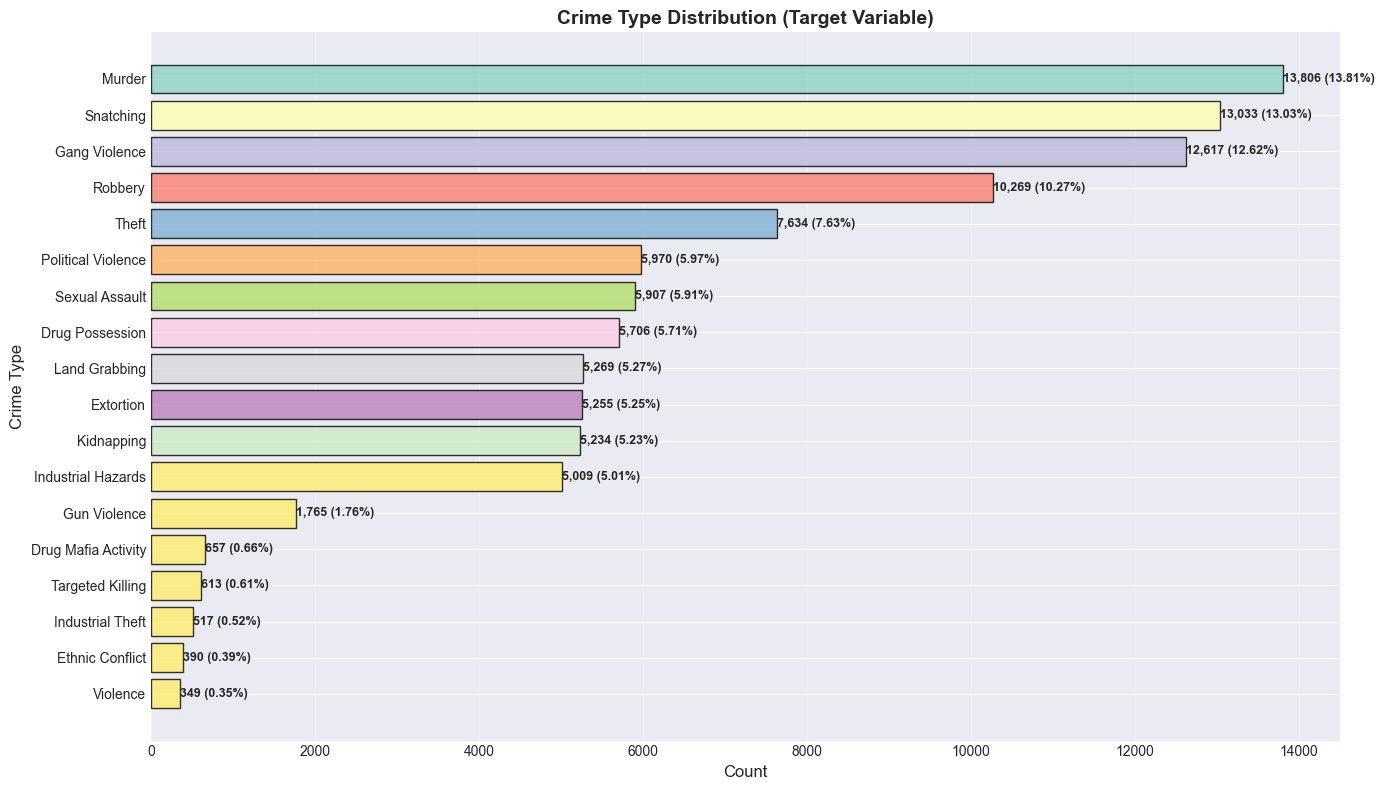

In [25]:
# Crime type distribution with percentages
crime_type_pct = df['CRIME_TYPE'].value_counts()

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(crime_type_pct)), crime_type_pct.values, 
               color=plt.cm.Set3(range(len(crime_type_pct))), edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(crime_type_pct)))
ax.set_yticklabels(crime_type_pct.index)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Crime Type', fontsize=12)
ax.set_title('Crime Type Distribution (Target Variable)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Add value labels with percentages
for i, bar in enumerate(bars):
    width = bar.get_width()
    percentage = (width / len(df)) * 100
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width):,} ({percentage:.2f}%)',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
# Calculate class imbalance ratio
print("=" * 80)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 80)

max_count = crime_type_counts.max()
min_count = crime_type_counts.min()
imbalance_ratio = max_count / min_count

print(f"Most common crime: {crime_type_counts.index[0]} ({max_count:,} cases)")
print(f"Least common crime: {crime_type_counts.index[-1]} ({min_count:,} cases)")
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"\nInterpretation: The most common crime type occurs {imbalance_ratio:.2f}x more than the least common.")

if imbalance_ratio > 10:
    print("⚠ WARNING: Severe class imbalance detected! Consider using techniques like SMOTE, class weights, or stratified sampling.")
elif imbalance_ratio > 5:
    print("⚠ CAUTION: Moderate class imbalance. May need to address during modeling.")
else:
    print("✓ Class distribution is relatively balanced.")

CLASS IMBALANCE ANALYSIS
Most common crime: Murder (13,806 cases)
Least common crime: Violence (349 cases)

Class Imbalance Ratio: 39.56:1

Interpretation: The most common crime type occurs 39.56x more than the least common.
⚠ WARNING: Severe class imbalance detected! Consider using techniques like SMOTE, class weights, or stratified sampling.


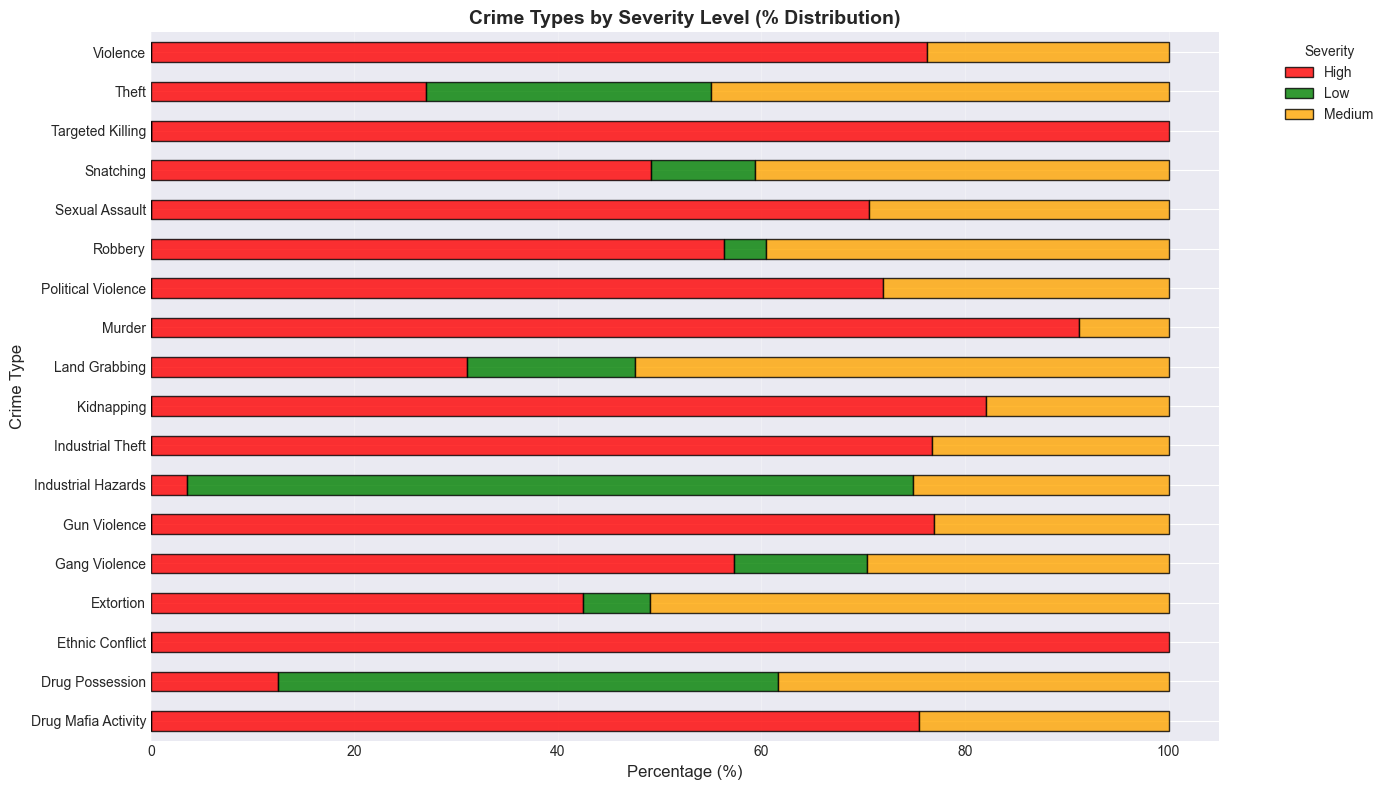

In [27]:
# Crime types by severity (stacked bar)
crime_severity_crosstab = pd.crosstab(df['CRIME_TYPE'], df['SEVERITY'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 8))
crime_severity_crosstab.plot(kind='barh', stacked=True, ax=ax,
                              color={'High': 'red', 'Medium': 'orange', 'Low': 'green'},
                              edgecolor='black', alpha=0.8)
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_ylabel('Crime Type', fontsize=12)
ax.set_title('Crime Types by Severity Level (% Distribution)', fontsize=14, fontweight='bold')
ax.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

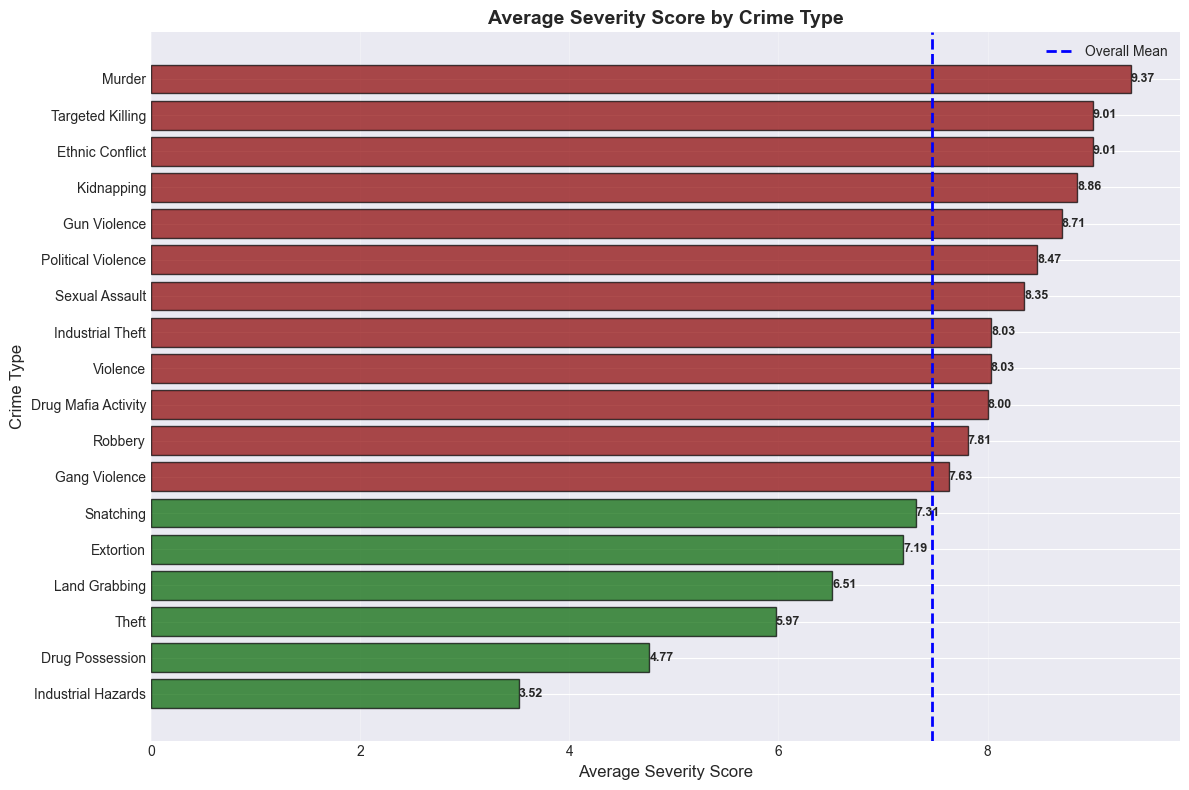

In [28]:
# Average severity score per crime type
avg_severity_by_crime = df.groupby('CRIME_TYPE')['SEVERITY_SCORE'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['darkred' if x > df['SEVERITY_SCORE'].mean() else 'darkgreen' for x in avg_severity_by_crime.values]
bars = ax.barh(range(len(avg_severity_by_crime)), avg_severity_by_crime.values,
               color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(avg_severity_by_crime)))
ax.set_yticklabels(avg_severity_by_crime.index)
ax.set_xlabel('Average Severity Score', fontsize=12)
ax.set_ylabel('Crime Type', fontsize=12)
ax.set_title('Average Severity Score by Crime Type', fontsize=14, fontweight='bold')
ax.axvline(df['SEVERITY_SCORE'].mean(), color='blue', linestyle='--', linewidth=2, label='Overall Mean')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.2f}',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 6: Temporal Analysis

In [29]:
# Extract temporal features
print("=" * 80)
print("EXTRACTING TEMPORAL FEATURES")
print("=" * 80)

df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month
df['DAY_OF_WEEK'] = df['DATE'].dt.dayofweek  # Monday=0, Sunday=6
df['DAY_NAME'] = df['DATE'].dt.day_name()
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([5, 6]).astype(int)
df['QUARTER'] = df['DATE'].dt.quarter

print("✓ Features extracted:")
print("  - YEAR")
print("  - MONTH")
print("  - DAY_OF_WEEK")
print("  - DAY_NAME")
print("  - IS_WEEKEND")
print("  - QUARTER")
print("\nSample:")
print(df[['DATE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'DAY_NAME', 'IS_WEEKEND', 'QUARTER']].head())

EXTRACTING TEMPORAL FEATURES
✓ Features extracted:
  - YEAR
  - MONTH
  - DAY_OF_WEEK
  - DAY_NAME
  - IS_WEEKEND
  - QUARTER

Sample:
        DATE  YEAR  MONTH  DAY_OF_WEEK  DAY_NAME  IS_WEEKEND  QUARTER
0 2024-12-15  2024     12            6    Sunday           1        4
1 2020-12-03  2020     12            3  Thursday           0        4
2 2025-01-24  2025      1            4    Friday           0        1
3 2023-02-18  2023      2            5  Saturday           1        1
4 2025-04-13  2025      4            6    Sunday           1        2


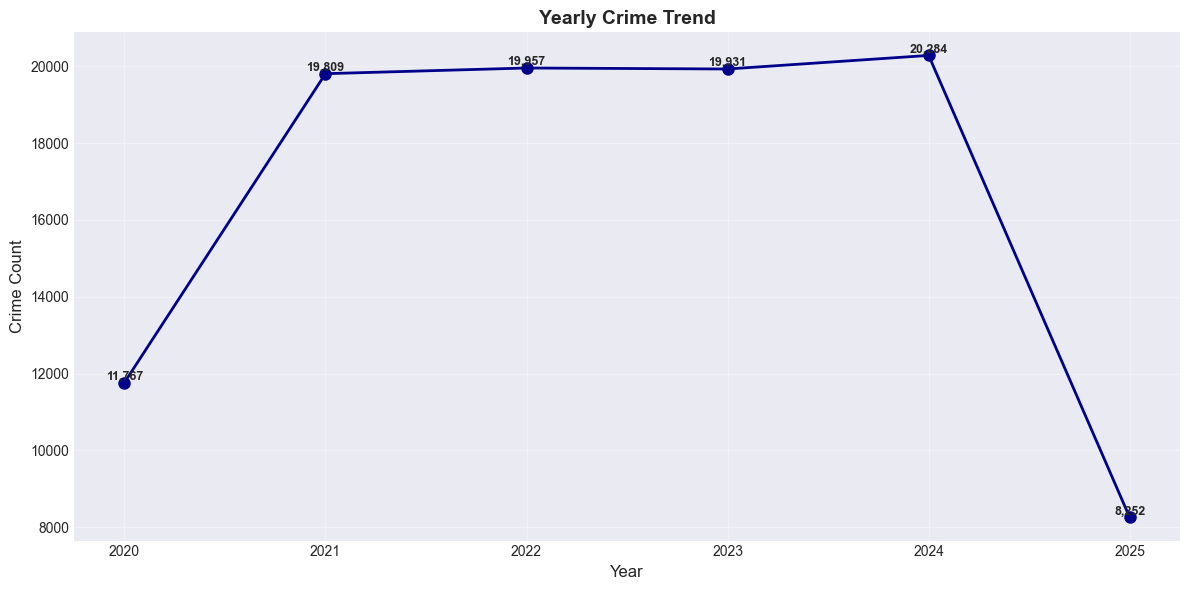

In [30]:
# Yearly trend
yearly_crimes = df['YEAR'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_crimes.index, yearly_crimes.values, marker='o', linewidth=2, markersize=8, color='darkblue')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Yearly Crime Trend', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# Add value labels
for x, y in zip(yearly_crimes.index, yearly_crimes.values):
    ax.text(x, y, f'{int(y):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

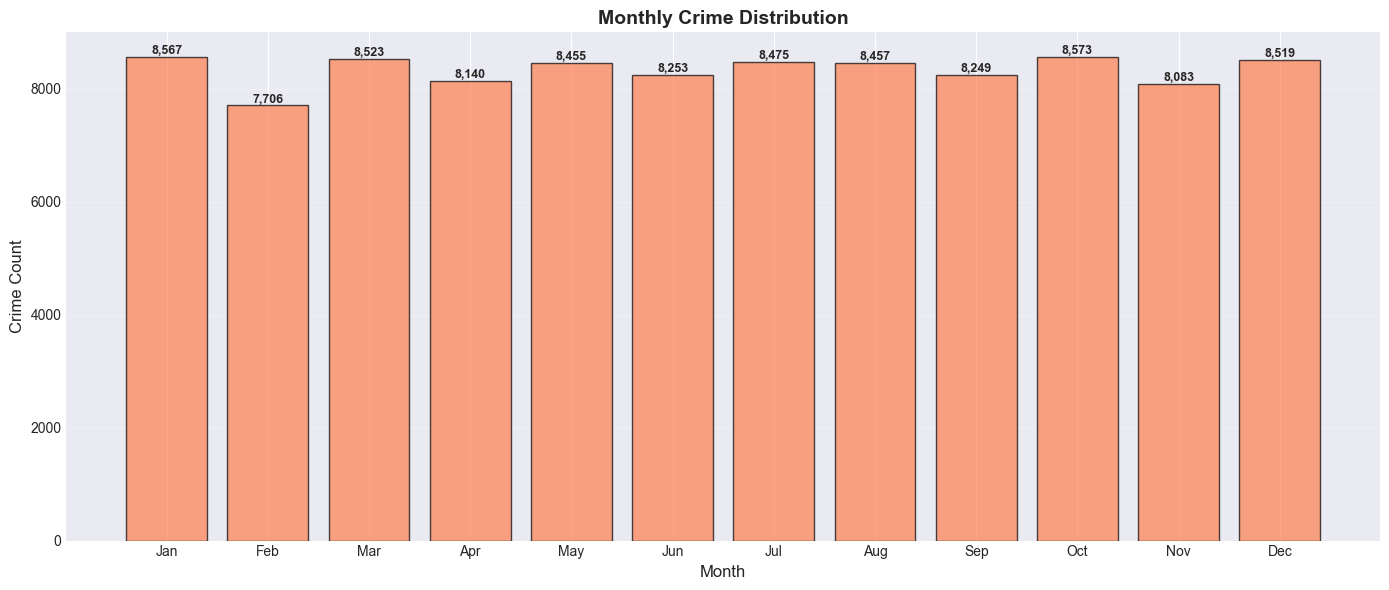

In [31]:
# Monthly distribution
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_crimes = df['MONTH'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(1, 13), [monthly_crimes.get(i, 0) for i in range(1, 13)],
              color='coral', edgecolor='black', alpha=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Monthly Crime Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

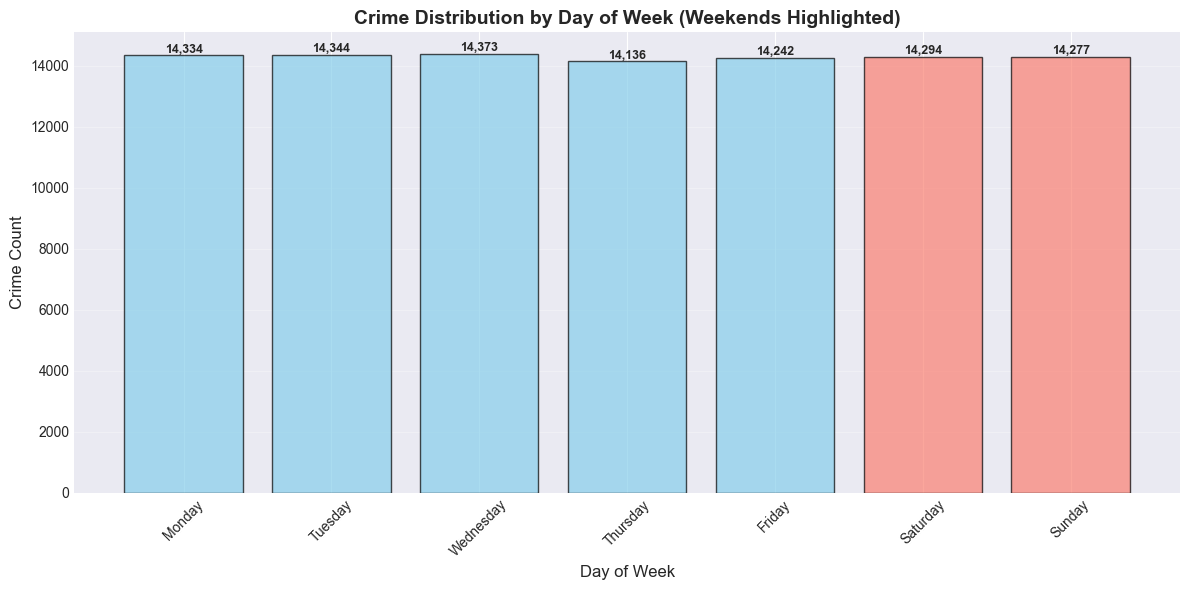

In [32]:
# Day of week distribution
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_crimes = df['DAY_NAME'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['salmon' if day in ['Saturday', 'Sunday'] else 'skyblue' for day in day_order]
bars = ax.bar(day_order, day_crimes.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Crime Distribution by Day of Week (Weekends Highlighted)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

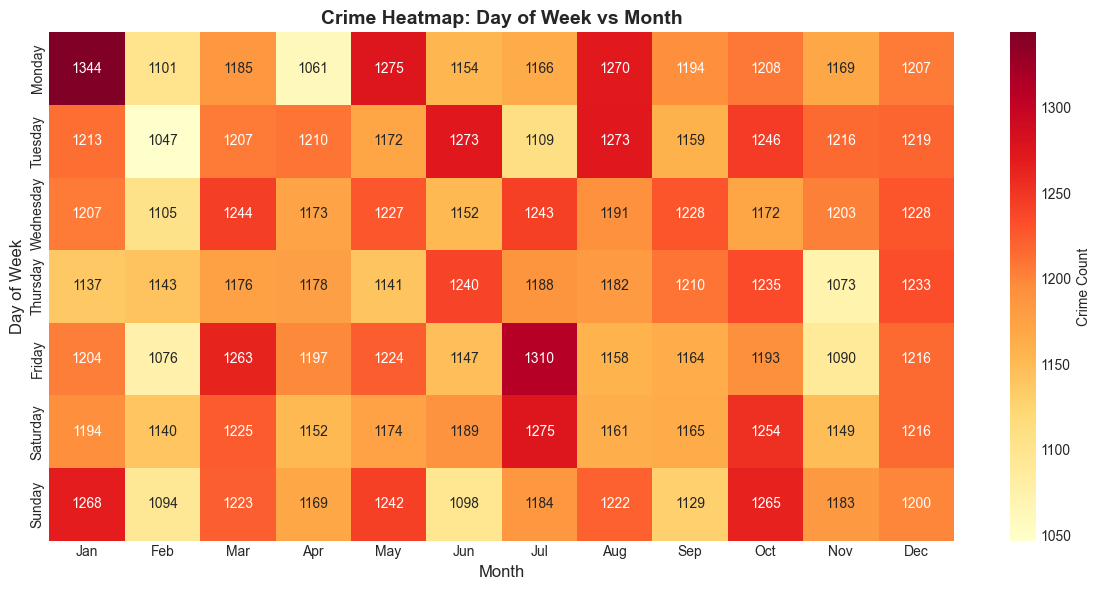

In [33]:
# Heatmap: Day of Week vs Month
heatmap_data = pd.crosstab(df['DAY_NAME'], df['MONTH'])
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Crime Count'})
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.set_title('Crime Heatmap: Day of Week vs Month', fontsize=14, fontweight='bold')
ax.set_xticklabels(month_names)

plt.tight_layout()
plt.show()

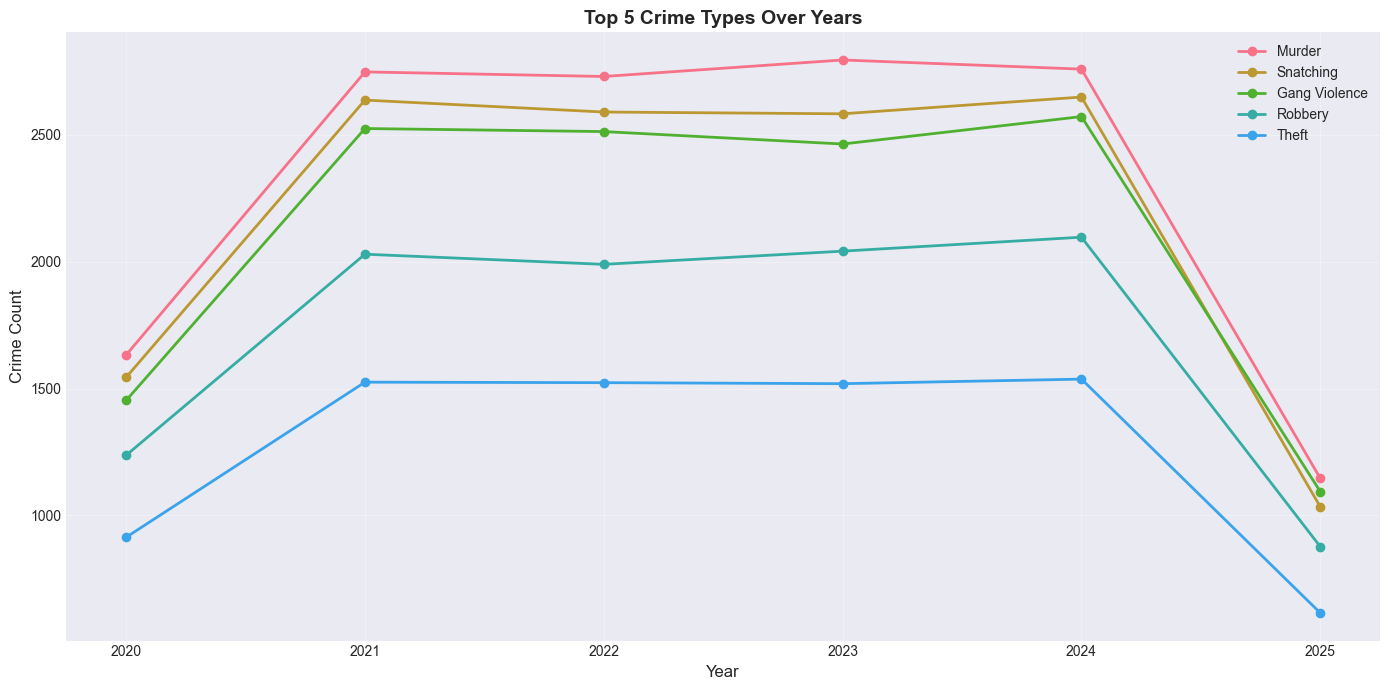

In [34]:
# Top 5 crime types over years
top_5_crimes = df['CRIME_TYPE'].value_counts().head(5).index
crime_year_data = df[df['CRIME_TYPE'].isin(top_5_crimes)].groupby(['YEAR', 'CRIME_TYPE']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
for crime in top_5_crimes:
    if crime in crime_year_data.columns:
        ax.plot(crime_year_data.index, crime_year_data[crime], marker='o', linewidth=2, markersize=6, label=crime)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Top 5 Crime Types Over Years', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 7: Geographical Analysis

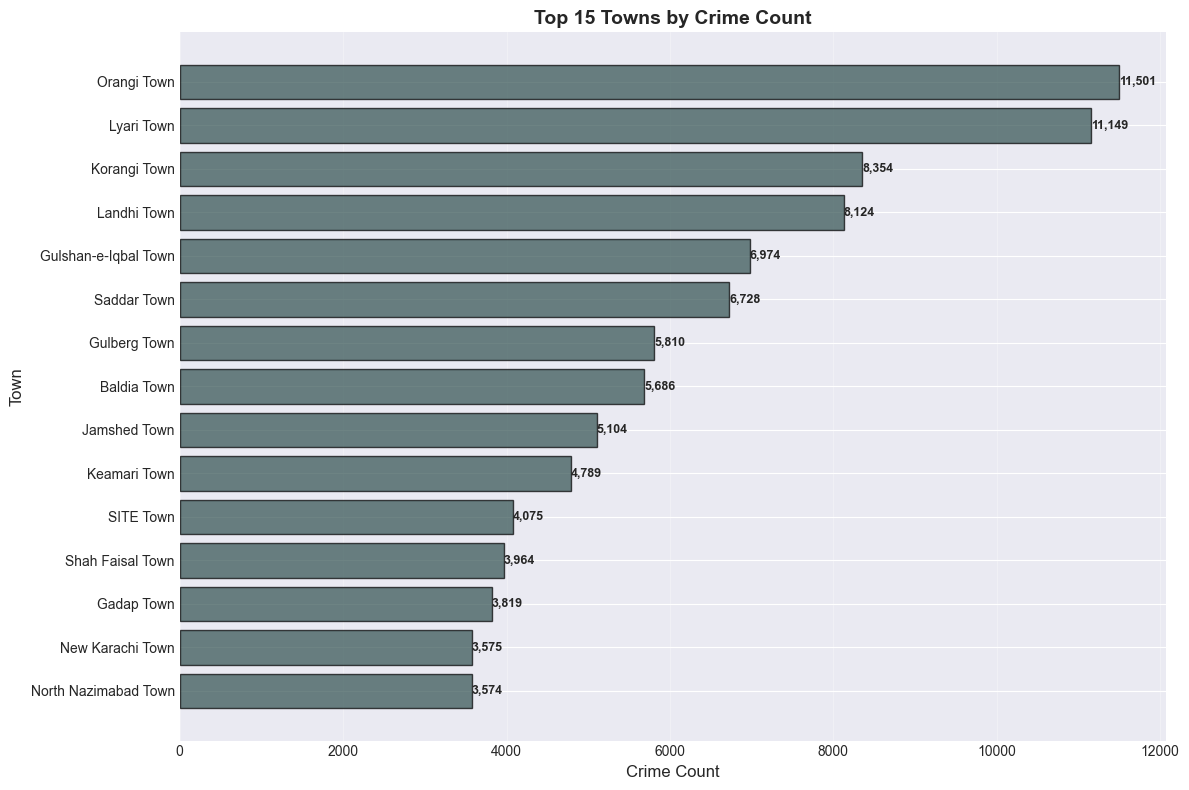

In [35]:
# Crimes by TOWN (top 15)
town_counts = df['TOWN'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(town_counts)), town_counts.values, color='darkslategray', edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(town_counts)))
ax.set_yticklabels(town_counts.index)
ax.set_xlabel('Crime Count', fontsize=12)
ax.set_ylabel('Town', fontsize=12)
ax.set_title('Top 15 Towns by Crime Count', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width):,}',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

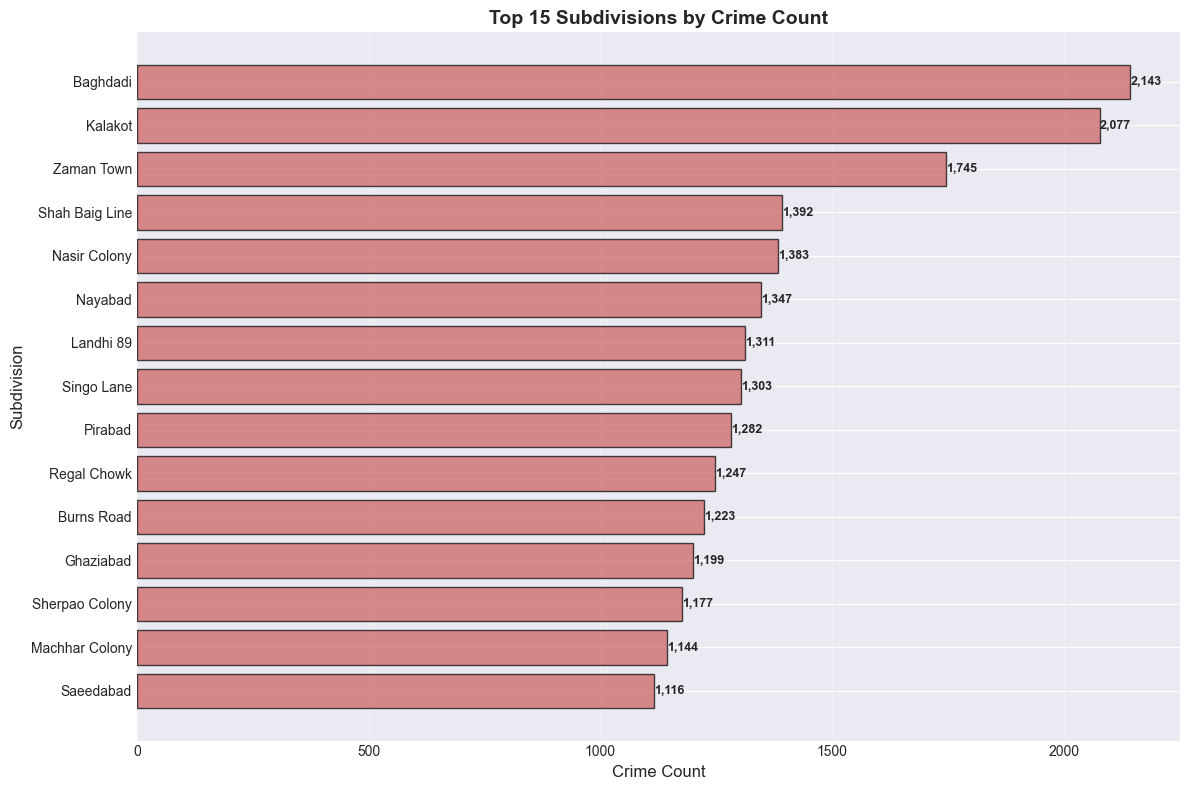

In [36]:
# Top 15 SUBDIVISIONs
subdivision_counts = df['SUBDIVISION'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(subdivision_counts)), subdivision_counts.values, color='indianred', edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(subdivision_counts)))
ax.set_yticklabels(subdivision_counts.index)
ax.set_xlabel('Crime Count', fontsize=12)
ax.set_ylabel('Subdivision', fontsize=12)
ax.set_title('Top 15 Subdivisions by Crime Count', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width):,}',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

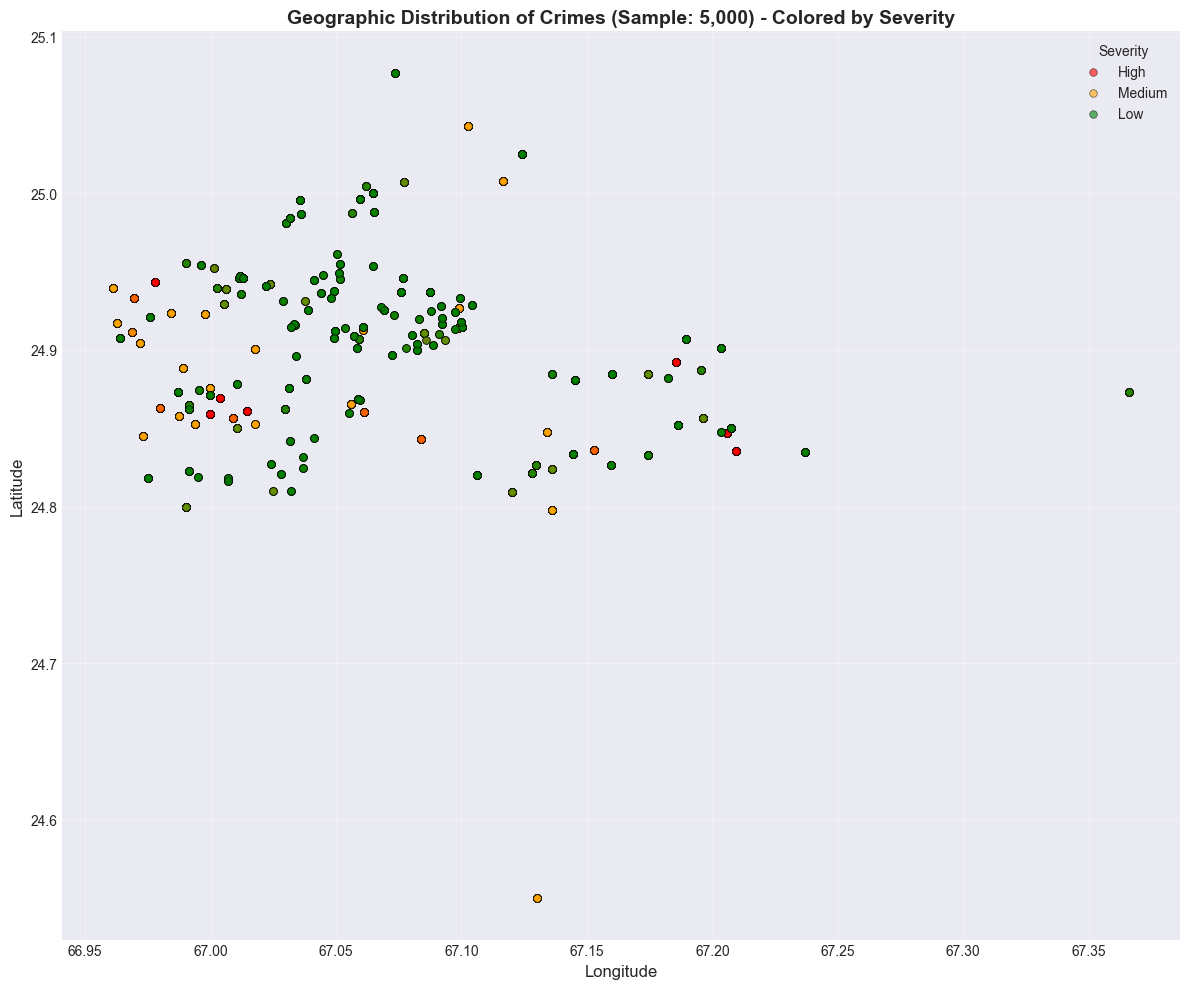

In [37]:
# Scatter plot of LAT/LONG colored by severity (sample 5000 for performance)
sample_df = df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 10))
severity_colors = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}

for severity, color in severity_colors.items():
    subset = sample_df[sample_df['SEVERITY'] == severity]
    ax.scatter(subset['LONGITUDE'], subset['LATITUDE'], c=color, label=severity, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Geographic Distribution of Crimes (Sample: 5,000) - Colored by Severity', fontsize=14, fontweight='bold')
ax.legend(title='Severity', loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

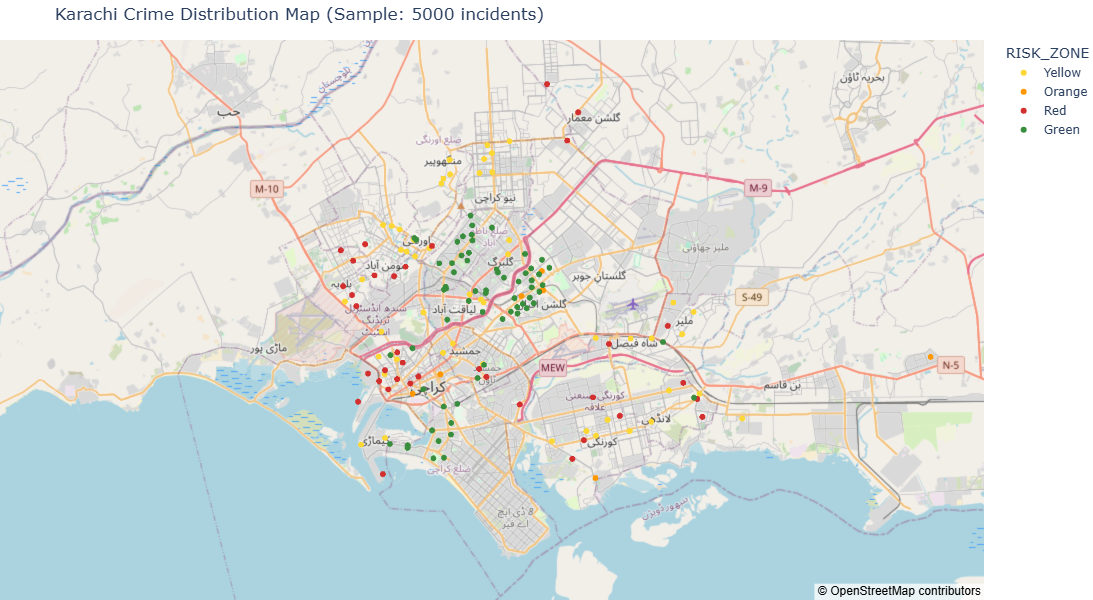


💡 Tip: Zoom in/out and hover over points to see crime details!


In [43]:
# Interactive scatter map using plotly
# Sample data for performance (plot every 100th point for clarity)
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

fig = px.scatter_mapbox(sample_df,
                        lat="LATITUDE",
                        lon="LONGITUDE",
                        color="RISK_ZONE",
                        color_discrete_map={'Red': '#d32f2f', 'Orange': '#ff9800',
                                           'Yellow': '#fdd835', 'Green': '#388e3c'},
                        hover_name="CRIME_TYPE",
                        hover_data=["TOWN", "SUBDIVISION", "SEVERITY"],
                        zoom=10,
                        height=600,
                        title="Karachi Crime Distribution Map (Sample: 5000 incidents)")

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

print("\n💡 Tip: Zoom in/out and hover over points to see crime details!")

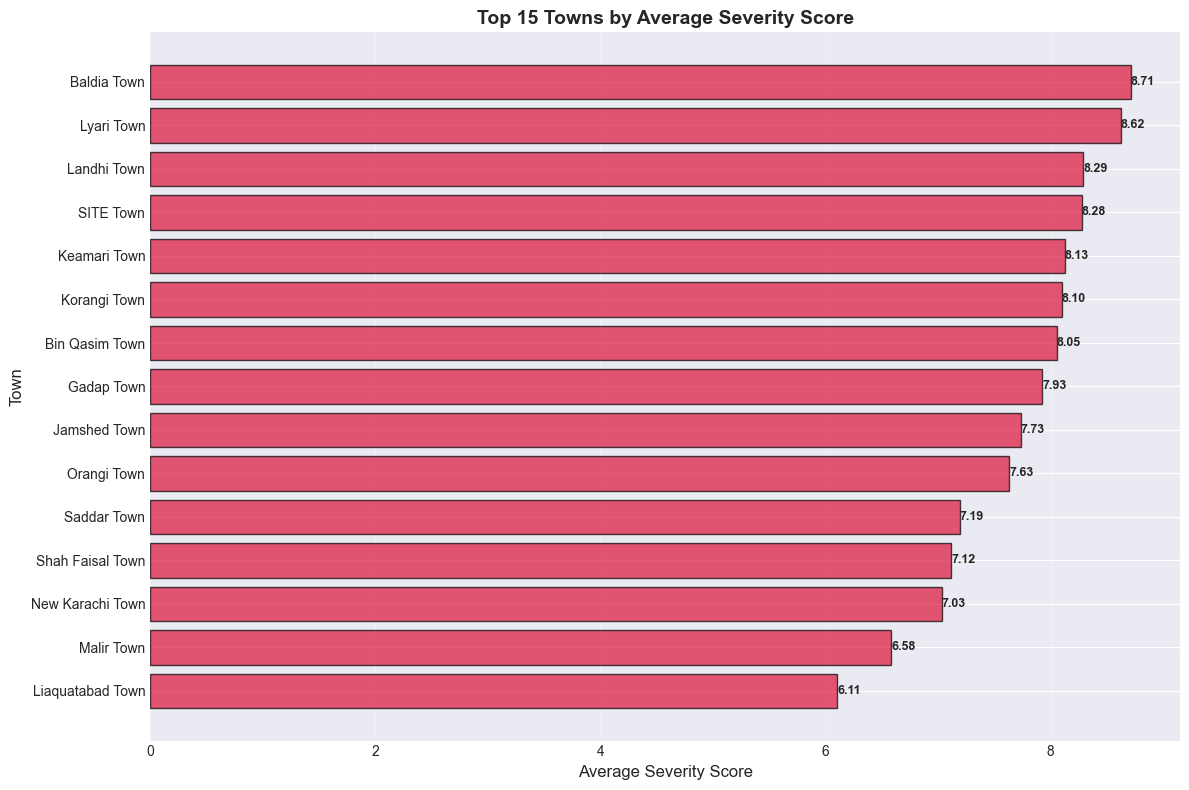

In [45]:
# Average severity score by town (top 15)
avg_severity_town = df.groupby('TOWN')['SEVERITY_SCORE'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(avg_severity_town)), avg_severity_town.values, color='crimson', edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(avg_severity_town)))
ax.set_yticklabels(avg_severity_town.index)
ax.set_xlabel('Average Severity Score', fontsize=12)
ax.set_ylabel('Town', fontsize=12)
ax.set_title('Top 15 Towns by Average Severity Score', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.2f}',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [47]:
df['RISK_ZONE'].unique()

array(['Red', 'Green', 'Yellow', 'Orange'], dtype=object)

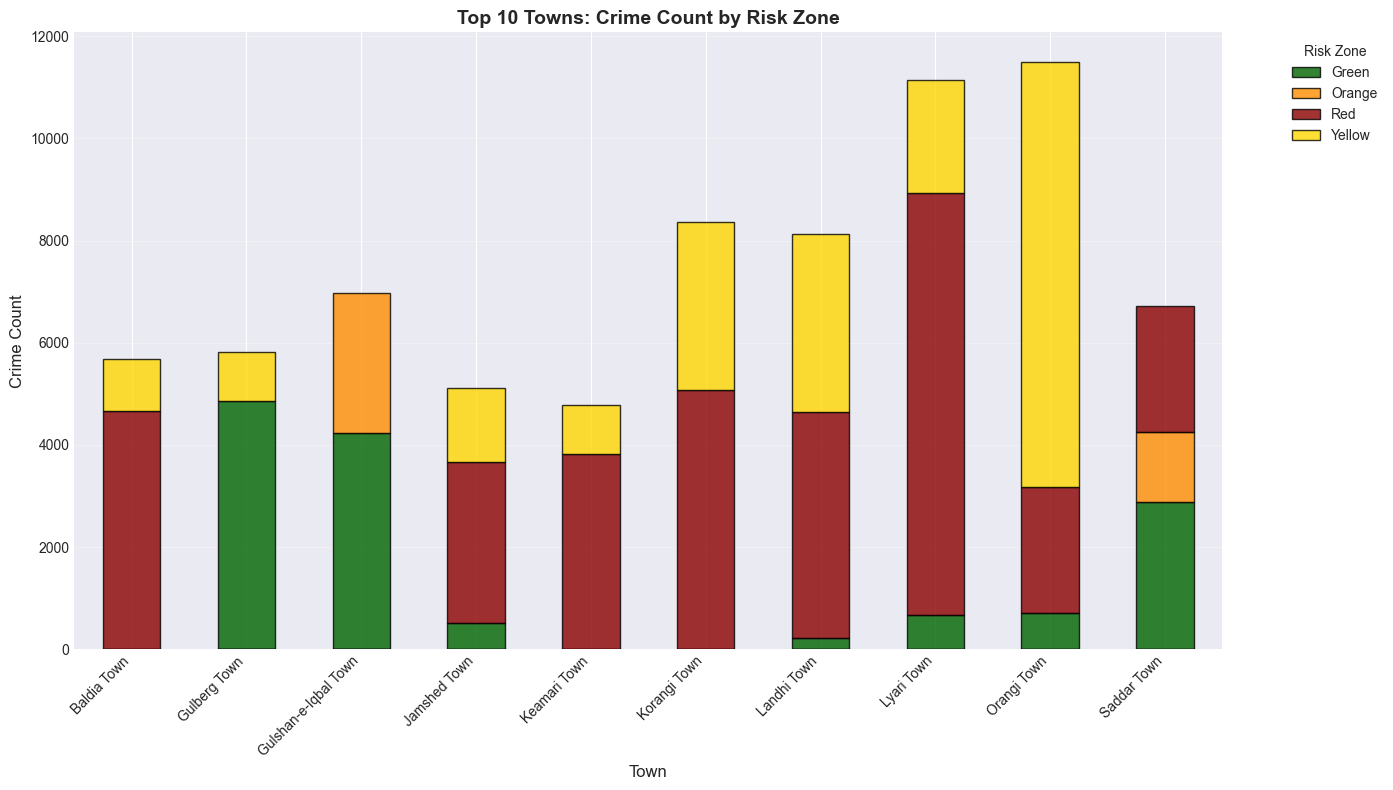

In [48]:
# Stacked bar: Town vs Risk Zone (top 10 towns)
top_10_towns = df['TOWN'].value_counts().head(10).index
town_risk_crosstab = pd.crosstab(df[df['TOWN'].isin(top_10_towns)]['TOWN'], 
                                  df[df['TOWN'].isin(top_10_towns)]['RISK_ZONE'])

fig, ax = plt.subplots(figsize=(14, 8))
town_risk_crosstab.plot(kind='bar', stacked=True, ax=ax,
                        color={
    'Red': 'darkred',
    'Orange': 'darkorange',
    'Yellow': 'gold',
    'Green': 'darkgreen'
}
,
                        edgecolor='black', alpha=0.8)
ax.set_xlabel('Town', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Top 10 Towns: Crime Count by Risk Zone', fontsize=14, fontweight='bold')
ax.legend(title='Risk Zone', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## Step 8: Bivariate Analysis

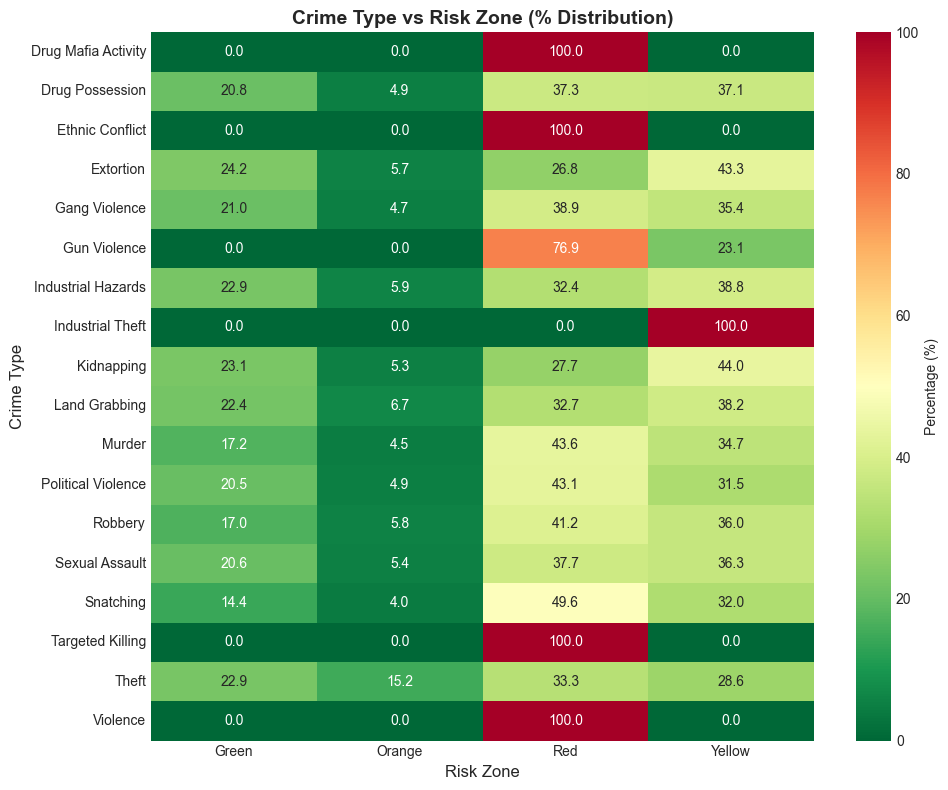

In [49]:
# Heatmap: Crime Type vs Risk Zone (normalized %)
crime_risk_crosstab = pd.crosstab(df['CRIME_TYPE'], df['RISK_ZONE'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(crime_risk_crosstab, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, 
            cbar_kws={'label': 'Percentage (%)'})
ax.set_xlabel('Risk Zone', fontsize=12)
ax.set_ylabel('Crime Type', fontsize=12)
ax.set_title('Crime Type vs Risk Zone (% Distribution)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

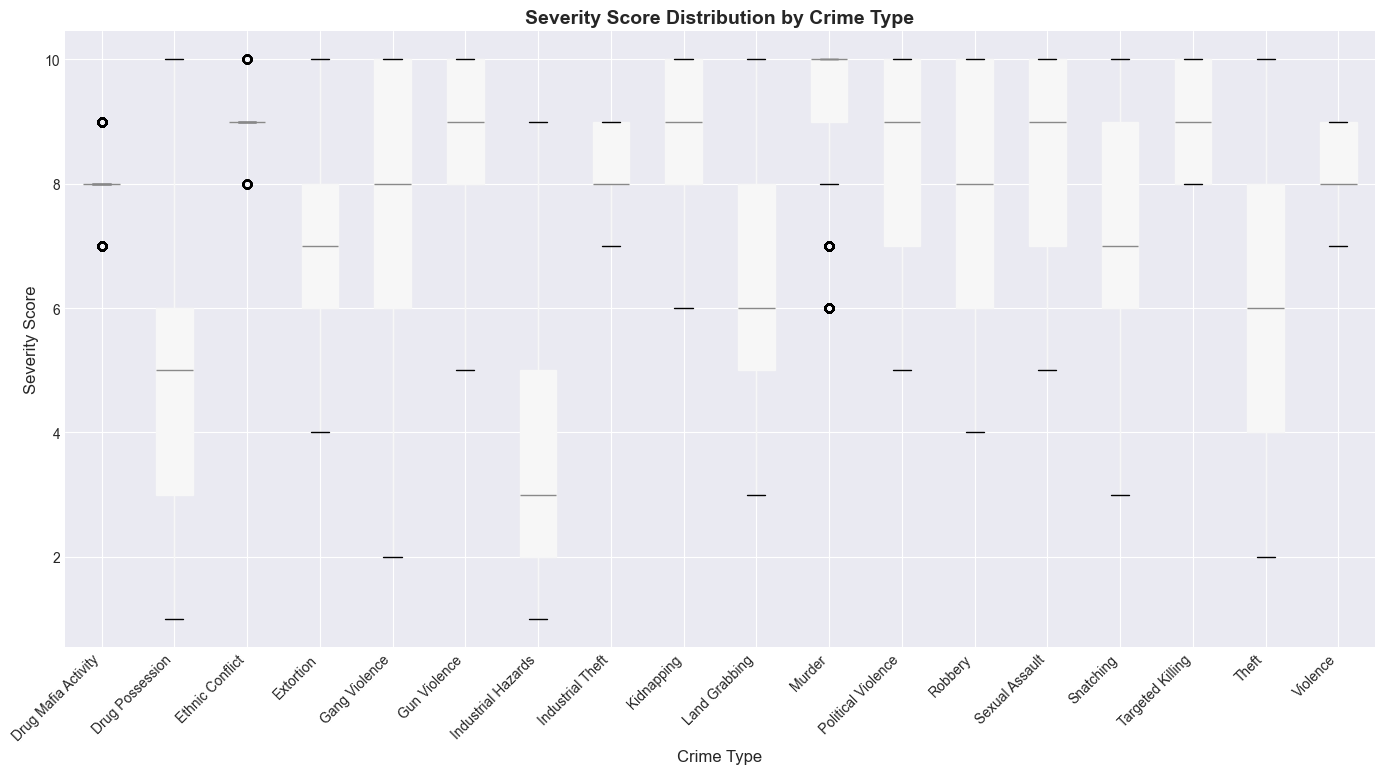

In [50]:
# Boxplot: Severity Score by Crime Type
fig, ax = plt.subplots(figsize=(14, 8))
df.boxplot(column='SEVERITY_SCORE', by='CRIME_TYPE', ax=ax, patch_artist=True)
ax.set_xlabel('Crime Type', fontsize=12)
ax.set_ylabel('Severity Score', fontsize=12)
ax.set_title('Severity Score Distribution by Crime Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

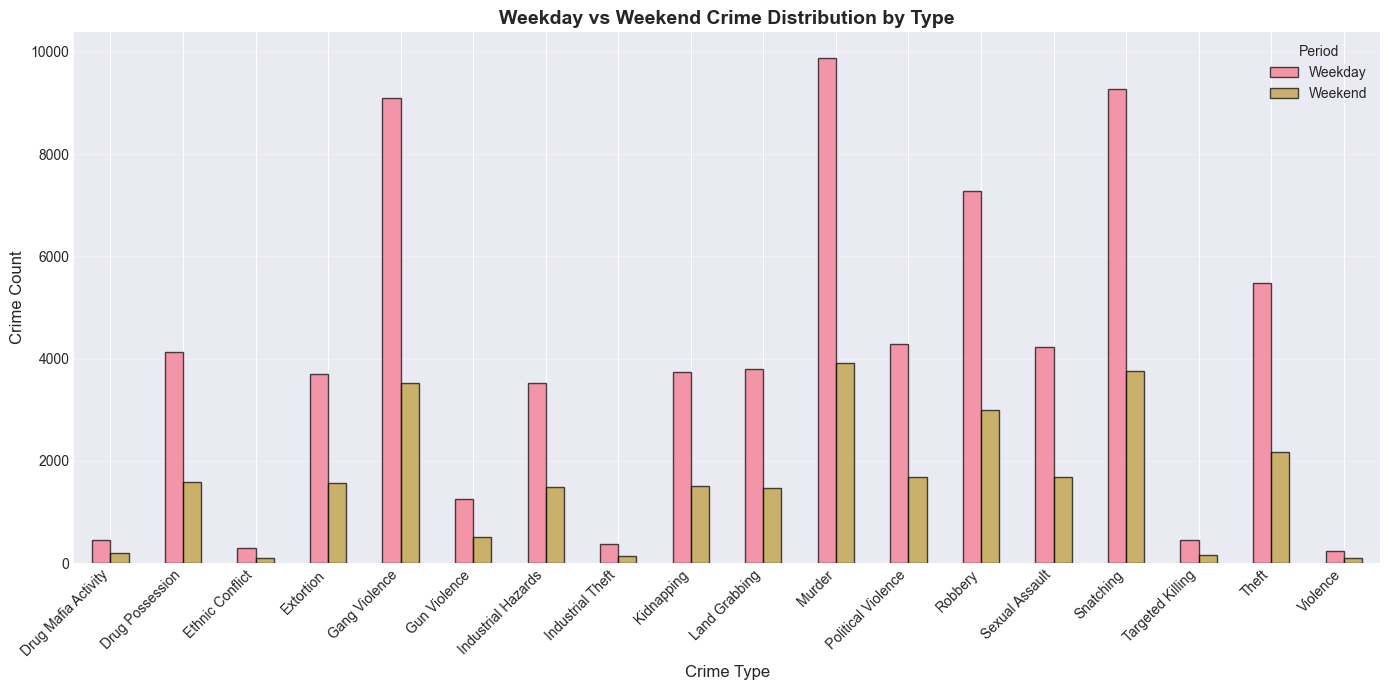

In [51]:
# Weekday vs Weekend crime distributions
weekday_weekend = df.groupby(['IS_WEEKEND', 'CRIME_TYPE']).size().unstack(fill_value=0)
weekday_weekend.index = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(14, 7))
weekday_weekend.T.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Crime Type', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Weekday vs Weekend Crime Distribution by Type', fontsize=14, fontweight='bold')
ax.legend(title='Period', loc='best')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

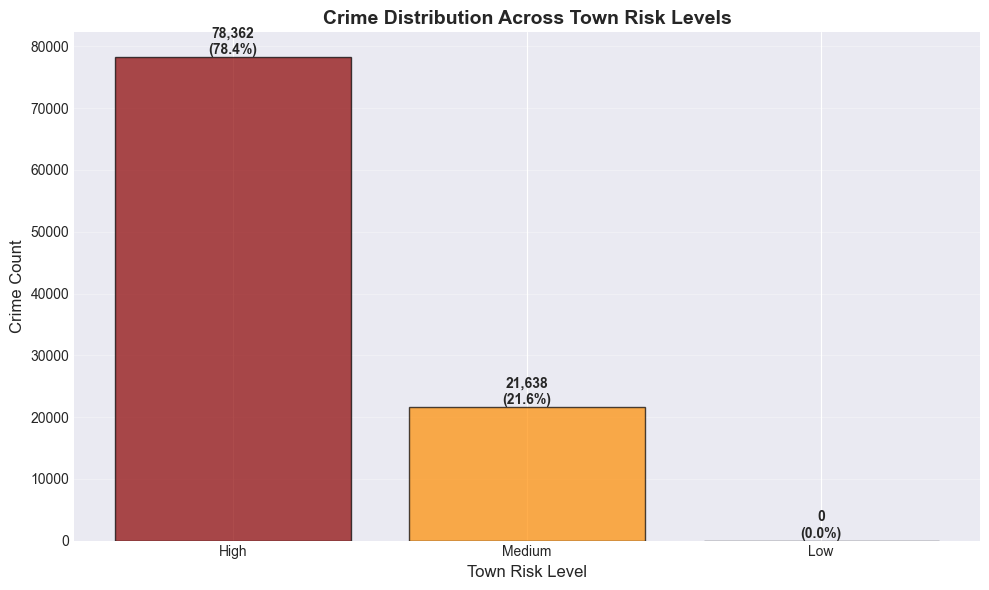

In [52]:
# Crime distribution across Town Risk Levels
# Assuming we can categorize towns by their average severity score
town_severity = df.groupby('TOWN')['SEVERITY_SCORE'].mean()
town_risk_level = pd.cut(town_severity, bins=[0, 3, 7, 10], labels=['Low', 'Medium', 'High'])
df['TOWN_RISK_LEVEL'] = df['TOWN'].map(town_risk_level)

town_risk_counts = df['TOWN_RISK_LEVEL'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'High': 'darkred', 'Medium': 'darkorange', 'Low': 'darkgreen'}
bar_colors = [colors.get(x, 'gray') for x in town_risk_counts.index]
bars = ax.bar(town_risk_counts.index, town_risk_counts.values, color=bar_colors, edgecolor='black', alpha=0.7)
ax.set_xlabel('Town Risk Level', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Crime Distribution Across Town Risk Levels', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 9: Correlation Analysis

In [53]:
# Select numerical columns for correlation analysis
numerical_cols = ['SEVERITY_SCORE', 'LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 
                  'DAY_OF_WEEK', 'IS_WEEKEND', 'QUARTER']

# Add zone flags if they exist
zone_cols = [col for col in df.columns if 'ZONE_' in col]
numerical_cols.extend(zone_cols)

# Filter to only existing columns
numerical_cols = [col for col in numerical_cols if col in df.columns]

print("=" * 80)
print("NUMERICAL COLUMNS FOR CORRELATION ANALYSIS")
print("=" * 80)
print(numerical_cols)

correlation_df = df[numerical_cols].corr()

NUMERICAL COLUMNS FOR CORRELATION ANALYSIS
['SEVERITY_SCORE', 'LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'QUARTER']


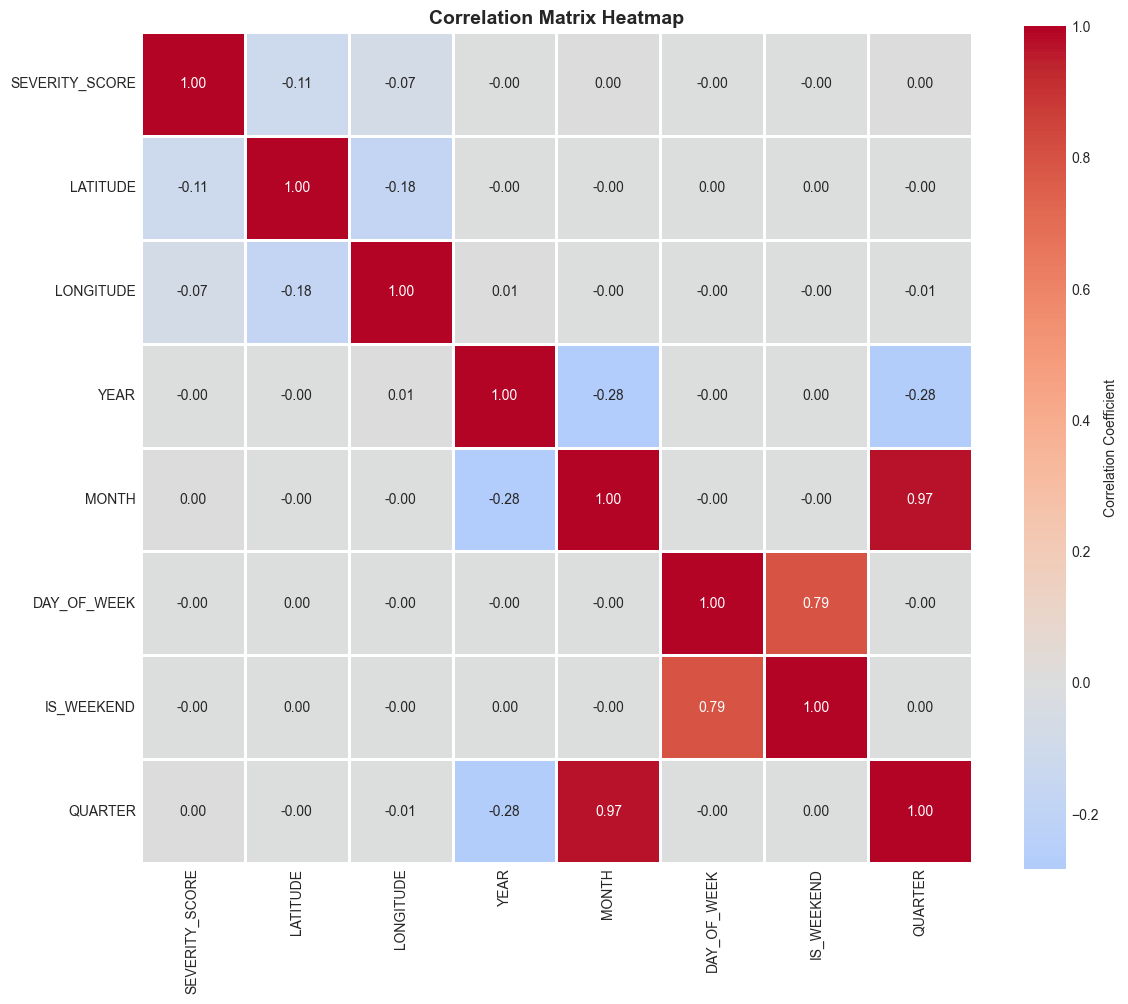

In [54]:
# Correlation matrix heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'}, ax=ax)
ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [55]:
# Top correlations with SEVERITY_SCORE
print("=" * 80)
print("TOP CORRELATIONS WITH SEVERITY_SCORE")
print("=" * 80)

severity_corr = correlation_df['SEVERITY_SCORE'].sort_values(ascending=False)
print(severity_corr)

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print("Correlation ranges from -1 to 1:")
print("  +1.0: Perfect positive correlation")
print("   0.0: No correlation")
print("  -1.0: Perfect negative correlation")
print("\nStrong correlations (|r| > 0.7) should be investigated for multicollinearity.")

TOP CORRELATIONS WITH SEVERITY_SCORE
SEVERITY_SCORE    1.00
QUARTER           0.00
MONTH             0.00
DAY_OF_WEEK      -0.00
IS_WEEKEND       -0.00
YEAR             -0.00
LONGITUDE        -0.07
LATITUDE         -0.11
Name: SEVERITY_SCORE, dtype: float64

INTERPRETATION
Correlation ranges from -1 to 1:
  +1.0: Perfect positive correlation
   0.0: No correlation
  -1.0: Perfect negative correlation

Strong correlations (|r| > 0.7) should be investigated for multicollinearity.


Generating pairplot for top 5 features correlated with SEVERITY_SCORE...
Features: ['SEVERITY_SCORE', 'QUARTER', 'MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND']


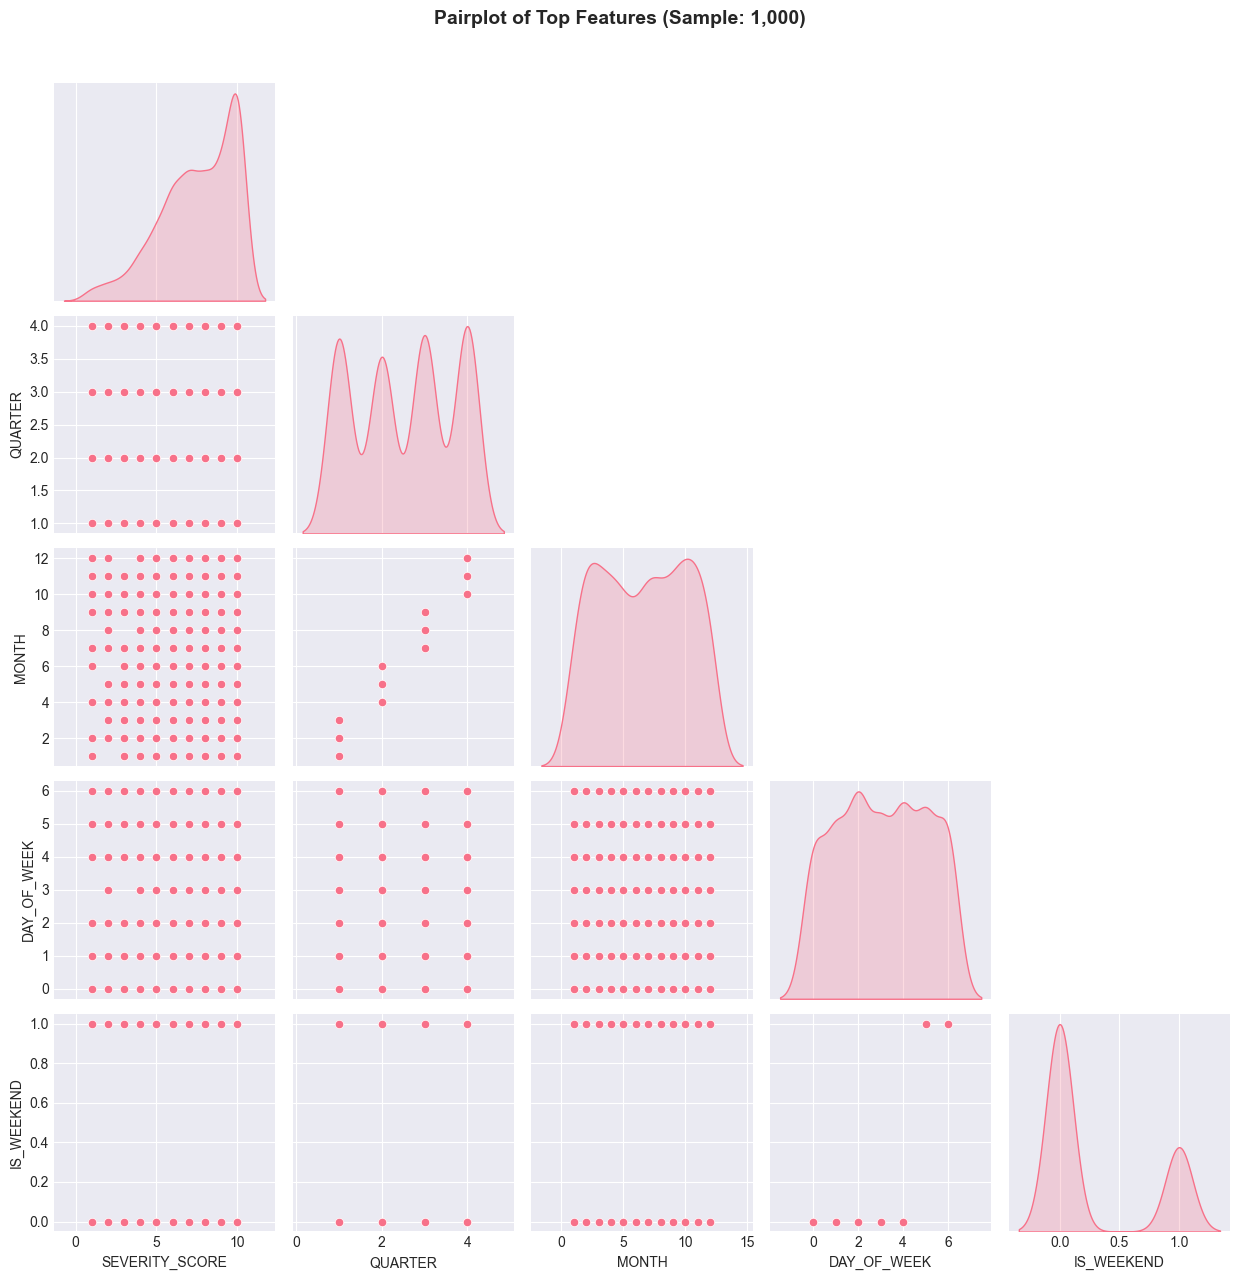

In [56]:
# Optional: Pairplot of key features (using sample for performance)
# Select top correlated features with SEVERITY_SCORE
top_features = severity_corr.head(5).index.tolist()
sample_for_pairplot = df[top_features].sample(1000, random_state=42)

print("Generating pairplot for top 5 features correlated with SEVERITY_SCORE...")
print(f"Features: {top_features}")

pairplot = sns.pairplot(sample_for_pairplot, diag_kind='kde', corner=True)
pairplot.fig.suptitle('Pairplot of Top Features (Sample: 1,000)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 10: Document Key Insights

In [57]:
print("=" * 80)
print("KEY INSIGHTS SUMMARY")
print("=" * 80)

print("\n1. DATASET SIZE & DATE RANGE")
print("-" * 80)
print(f"   Total Records: {len(df):,}")
print(f"   Date Range: {df['DATE'].min().strftime('%Y-%m-%d')} to {df['DATE'].max().strftime('%Y-%m-%d')}")
print(f"   Years Covered: {df['YEAR'].nunique()} years ({df['YEAR'].min()} - {df['YEAR'].max()})")
print(f"   Total Columns: {df.shape[1]}")

print("\n2. TARGET VARIABLE DISTRIBUTION & IMBALANCE")
print("-" * 80)
crime_counts = df['CRIME_TYPE'].value_counts()
print(f"   Number of Crime Types: {len(crime_counts)}")
print(f"   Most Common: {crime_counts.index[0]} ({crime_counts.iloc[0]:,} cases, {crime_counts.iloc[0]/len(df)*100:.2f}%)")
print(f"   Least Common: {crime_counts.index[-1]} ({crime_counts.iloc[-1]:,} cases, {crime_counts.iloc[-1]/len(df)*100:.2f}%)")
imbalance = crime_counts.iloc[0] / crime_counts.iloc[-1]
print(f"   Class Imbalance Ratio: {imbalance:.2f}:1")
if imbalance > 10:
    print("   ⚠ RECOMMENDATION: Use SMOTE, class weights, or stratified sampling")

print("\n3. MOST/LEAST COMMON CRIME TYPES")
print("-" * 80)
print("   Top 3 Crime Types:")
for i, (crime, count) in enumerate(crime_counts.head(3).items(), 1):
    print(f"      {i}. {crime}: {count:,} ({count/len(df)*100:.2f}%)")
print("   \n   Bottom 3 Crime Types:")
for i, (crime, count) in enumerate(crime_counts.tail(3).items(), 1):
    print(f"      {i}. {crime}: {count:,} ({count/len(df)*100:.2f}%)")

print("\n4. HIGH-RISK TOWNS AND SUBDIVISIONS")
print("-" * 80)
top_3_towns = df['TOWN'].value_counts().head(3)
print("   Top 3 Towns by Crime Count:")
for i, (town, count) in enumerate(top_3_towns.items(), 1):
    print(f"      {i}. {town}: {count:,} ({count/len(df)*100:.2f}%)")

top_3_subdivisions = df['SUBDIVISION'].value_counts().head(3)
print("   \n   Top 3 Subdivisions by Crime Count:")
for i, (subdivision, count) in enumerate(top_3_subdivisions.items(), 1):
    print(f"      {i}. {subdivision}: {count:,} ({count/len(df)*100:.2f}%)")

print("\n5. TEMPORAL PATTERNS")
print("-" * 80)
peak_year = df['YEAR'].value_counts().idxmax()
peak_year_count = df['YEAR'].value_counts().max()
print(f"   Peak Year: {peak_year} ({peak_year_count:,} crimes)")

peak_month = df['MONTH'].value_counts().idxmax()
peak_month_count = df['MONTH'].value_counts().max()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print(f"   Peak Month: {month_names[peak_month-1]} ({peak_month_count:,} crimes)")

peak_day = df['DAY_NAME'].value_counts().idxmax()
peak_day_count = df['DAY_NAME'].value_counts().max()
print(f"   Peak Day of Week: {peak_day} ({peak_day_count:,} crimes)")

weekend_crimes = df[df['IS_WEEKEND'] == 1].shape[0]
weekday_crimes = df[df['IS_WEEKEND'] == 0].shape[0]
print(f"   Weekend vs Weekday: {weekend_crimes:,} ({weekend_crimes/len(df)*100:.2f}%) vs {weekday_crimes:,} ({weekday_crimes/len(df)*100:.2f}%)")

print("\n6. SEVERITY PATTERNS")
print("-" * 80)
severity_dist = df['SEVERITY'].value_counts()
for severity, count in severity_dist.items():
    print(f"   {severity}: {count:,} ({count/len(df)*100:.2f}%)")
print(f"   \n   Mean Severity Score: {df['SEVERITY_SCORE'].mean():.2f}")
print(f"   Median Severity Score: {df['SEVERITY_SCORE'].median():.2f}")

print("\n7. FEATURE ENGINEERING RECOMMENDATIONS")
print("-" * 80)
print("   ✓ Temporal features already extracted: YEAR, MONTH, DAY_OF_WEEK, IS_WEEKEND, QUARTER")
print("   ✓ Consider adding:")
print("      - Time-based aggregations (crimes per town per month)")
print("      - Rolling averages of crime rates")
print("      - Distance from city center (using LAT/LONG)")
print("      - Interaction features (e.g., RISK_ZONE × SEVERITY)")
print("      - Crime density features (crimes per area)")
print("      - Historical crime rate for each location")
print("   ✓ Encoding strategies:")
print("      - One-hot encoding for CRIME_TYPE, SEVERITY, RISK_ZONE")
print("      - Target encoding for high-cardinality features (TOWN, SUBDIVISION)")
print("      - Cyclic encoding for MONTH, DAY_OF_WEEK")

print("\n8. DATA QUALITY NOTES")
print("-" * 80)
missing_summary = df.isnull().sum().sum()
duplicate_summary = df.duplicated().sum()
print(f"   Total Missing Values: {missing_summary}")
print(f"   Total Duplicate Rows: {duplicate_summary}")
print(f"   INCIDENT_ID Uniqueness: {df['INCIDENT_ID'].nunique() == len(df)}")

print("\n" + "=" * 80)
print("EDA COMPLETE - Ready for Preprocessing & Feature Engineering!")
print("=" * 80)

KEY INSIGHTS SUMMARY

1. DATASET SIZE & DATE RANGE
--------------------------------------------------------------------------------
   Total Records: 100,000
   Date Range: 2020-06-01 to 2025-05-31
   Years Covered: 6 years (2020 - 2025)
   Total Columns: 27

2. TARGET VARIABLE DISTRIBUTION & IMBALANCE
--------------------------------------------------------------------------------
   Number of Crime Types: 18
   Most Common: Murder (13,806 cases, 13.81%)
   Least Common: Violence (349 cases, 0.35%)
   Class Imbalance Ratio: 39.56:1
   ⚠ RECOMMENDATION: Use SMOTE, class weights, or stratified sampling

3. MOST/LEAST COMMON CRIME TYPES
--------------------------------------------------------------------------------
   Top 3 Crime Types:
      1. Murder: 13,806 (13.81%)
      2. Snatching: 13,033 (13.03%)
      3. Gang Violence: 12,617 (12.62%)
   
   Bottom 3 Crime Types:
      1. Industrial Theft: 517 (0.52%)
      2. Ethnic Conflict: 390 (0.39%)
      3. Violence: 349 (0.35%)

4. HIGH

---
## Next Steps

Based on this EDA, the next notebook should focus on:

1. **Data Preprocessing**
   - Handle any data quality issues identified
   - Normalize/standardize numerical features
   - Encode categorical variables

2. **Feature Engineering**
   - Create additional temporal features
   - Generate location-based features
   - Build interaction features
   - Implement target encoding for high-cardinality features

3. **Feature Selection**
   - Remove highly correlated features
   - Use importance-based selection methods
   - Reduce dimensionality if needed

4. **Class Imbalance Handling**
   - Implement SMOTE or other resampling techniques
   - Set up class weights for models
   - Consider stratified sampling

5. **Train/Test Split**
   - Time-based split (if temporal ordering matters)
   - Stratified split to maintain class distribution

---
**End of EDA Notebook**